In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
import noiseProjectBase as npb

In [43]:
def idealPSD(color, omegaList, tau):
    psdList = np.zeros(len(omegaList))
    positive = omegaList>0.0
    omega = omegaList[positive]
    if (color.lower() == "white"):
        psdList[positive] = 1.0
    elif (color.lower() == "pink"):
        psdList[positive] = 1.0/np.sqrt(omega*omega+1.0/tau*tau)
    elif (color.lower() == "brownian"):
        psdList[positive] = 1.0/(omega*omega+1.0/tau*tau)
    elif (color.lower() == "blue"):
        psdList[positive] = omega
    elif (color.lower() == "violet"):
        psdList[positive] = omega*omega
    elif (color.lower() == "lorentzian"):
        psdList[positive] = tau/(np.pi*(1.0+omega*omega*tau*tau))
    return psdList

In [45]:
def generateNoiseFromPSD(color, sigma, tau, deltat, tmax, seed = None):
    rng = np.random.default_rng(seed)
    numSteps = int(np.round(tmax/deltat))
    generatedTmax = numSteps*deltat
    frequencyList = np.fft.rfftfreq(numSteps, deltat)
    omegaList = 2.0*np.pi*frequencyList
    psdShape = idealPSD(color, omegaList, tau)
    weights = np.full(len(psdShape), 2.0)
    weights[0] = 1.0
    if (numSteps%2 == 0):
        weights[-1] = 1.0
    rawVariance = np.sum(weights*psdShape)/(numSteps**2)
    normalization = sigma/np.sqrt(rawVariance)
    randomPhase = rng.uniform(0.0, 2.0*np.pi, len(psdShape))
    frequencyNoise = normalization*np.sqrt(psdShape)*np.exp(1.0j*randomPhase)
    frequencyNoise[0] = 0.0
    if (numSteps%2 == 0):
        frequencyNoise[-1] = normalization*np.sqrt(psdShape[-1])*rng.choice([-1.0, 1.0])
    noiseList = np.fft.irfft(frequencyNoise, n = numSteps)
    timeList = np.arange(numSteps)*deltat
    theoreticalVariance = np.sum(weights*(normalization**2)*psdShape)/(numSteps**2)
    return timeList, noiseList, frequencyList, omegaList, psdShape, theoreticalVariance

In [4]:
def generateColoredNoiseData(color, sigma, tau, numTrials, deltat, tmax, seed = 1):
    experimentalSteps = int(np.round(tmax/deltat))+1
    generatedTmax = max(50.0*tau, 20.0*tmax)
    noiseData = []
    theoreticalVarianceList = []
    for trial in range(numTrials):
        timeLong, noiseLong, frequencyList, omegaList, psdShape, theoreticalVariance = generateNoiseFromPSD(color, sigma, tau, deltat, generatedTmax, seed+trial)
        rng = np.random.default_rng(seed+100000+trial)
        maximumStart = len(noiseLong)-experimentalSteps
        startIndex = rng.integers(0, maximumStart+1)
        noiseWindow = noiseLong[startIndex:startIndex+experimentalSteps]
        noiseData.append(noiseWindow)
        theoreticalVarianceList.append(theoreticalVariance)
    timeList = np.arange(experimentalSteps)*deltat
    return timeList, np.array(noiseData), frequencyList, omegaList, psdShape, np.mean(theoreticalVarianceList)

In [5]:
def averagedTrajectories(noiseData, B0, deltat):
    numTrials, numSteps = noiseData.shape
    timeList = np.arange(numSteps)*deltat
    totalField = B0+noiseData
    phaseNoEcho = np.zeros((numTrials, numSteps))
    phaseNoEcho[:, 1:] = np.cumsum(totalField[:, :-1], axis = 1)*deltat
    xNoEchoTrials = np.cos(2.0*phaseNoEcho)
    midpoint = (numSteps-1)//2
    signList = np.ones(numSteps-1)
    signList[midpoint:] = -1.0
    phaseEcho = np.zeros((numTrials, numSteps))
    phaseEcho[:, 1:] = np.cumsum(totalField[:, :-1]*signList, axis = 1)*deltat
    xEchoTrials = np.cos(2.0*phaseEcho)
    noNoisePhase = B0*timeList
    noNoiseNoEcho = np.cos(2.0*noNoisePhase)
    noNoiseEchoPhase = np.zeros(numSteps)
    noNoiseEchoPhase[1:] = np.cumsum(B0*signList)*deltat
    noNoiseEcho = np.cos(2.0*noNoiseEchoPhase)
    averageNoEcho = np.mean(xNoEchoTrials, axis = 0)
    averageEcho = np.mean(xEchoTrials, axis = 0)
    return timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials

In [24]:
def plotIdealPSDs(sigma, tau, deltat, tmax):
    frequencyList = np.fft.rfftfreq(int(tmax/deltat), deltat)
    omegaList = 2*np.pi*frequencyList
    positiveOmegaList = omegaList[1:]
    unnormalizedPSDData = {
        "White": np.ones(len(positiveOmegaList)),
        "Pink": 1/np.sqrt(positiveOmegaList**2+tau**2),
        "Brownian": 1/(positiveOmegaList**2+tau**2),
        "Blue": positiveOmegaList,
        "Violet": positiveOmegaList**2,
        "Lorentzian": tau/(np.pi*(1+positiveOmegaList**2*tau**2))
    }
    normalizedPSDData = {}
    for color, psdList in unnormalizedPSDData.items():
        theoreticalVariance = np.trapz(psdList, positiveOmegaList)/np.pi
        normalizedPSDData[color] = psdList*(sigma**2/theoreticalVariance)
    plt.figure(figsize = (10, 6))
    for color, psdList in normalizedPSDData.items():
        plt.loglog(positiveOmegaList, psdList, linewidth = 2, label = color)
    plt.xlabel(r"Angular Frequency $\omega$", fontsize = 15)
    plt.ylabel(r"Power Spectral Density $S(\omega)$", fontsize = 15)
    plt.title("Ideal Power Spectral Densities", fontsize = 17)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.legend(fontsize = 11, frameon = False)
    plt.tight_layout()
    plt.show()

In [6]:
B0 = 1.0
sigma = 0.5
tau = 5.0
deltat = 0.001
tmax = 5.0
numTrials = 500
seed = 1
colorList = ["white", "pink", "brownian", "blue", "violet", "lorentzian"]

In [7]:
noiseDataDictionary = {}
trajectoryDictionary = {}
theoreticalVarianceDictionary = {}
psdDictionary = {}

for index, color in enumerate(colorList):
    timeList, noiseData, frequencyList, omegaList, psdShape, theoreticalVariance = generateColoredNoiseData(color, sigma, tau, numTrials, deltat, tmax, seed+index*10000)
    trajectoryResults = averagedTrajectories(noiseData, B0, deltat)
    noiseDataDictionary[color] = noiseData
    trajectoryDictionary[color] = trajectoryResults
    theoreticalVarianceDictionary[color] = theoreticalVariance
    psdDictionary[color] = psdShape

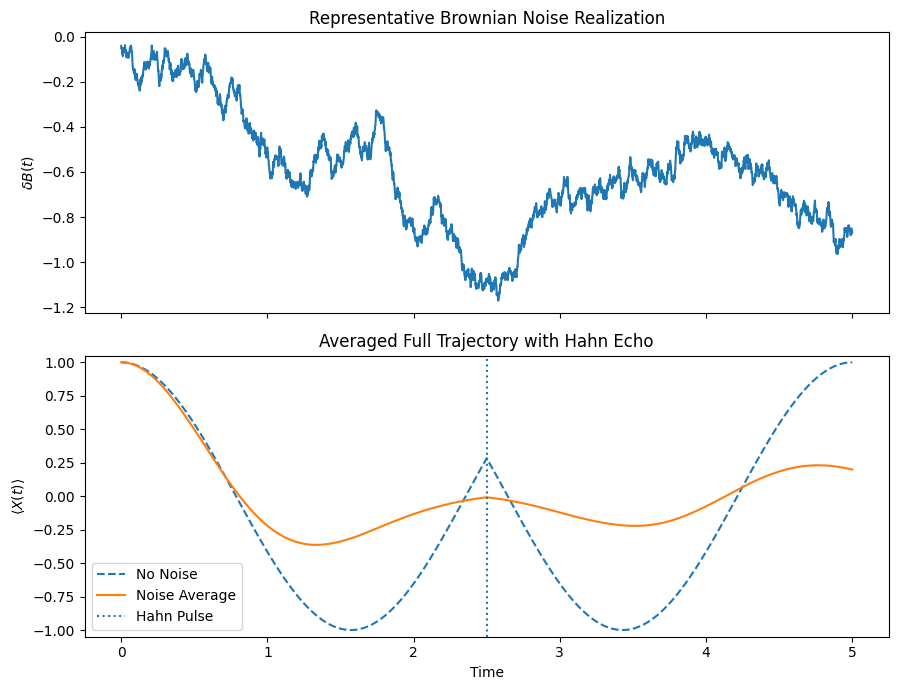

In [8]:
representativeColor = "brownian"
noiseData = noiseDataDictionary[representativeColor]
timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials = trajectoryDictionary[representativeColor]

figure, axes = plt.subplots(2, 1, figsize = (9, 7), sharex = True)
axes[0].plot(timeList, noiseData[0])
axes[0].set_ylabel(r"$\delta B(t)$")
axes[0].set_title("Representative "+representativeColor.capitalize()+" Noise Realization")
axes[1].plot(timeList, noNoiseEcho, linestyle = "--", label = "No Noise")
axes[1].plot(timeList, averageEcho, label = "Noise Average")
axes[1].axvline(tmax/2.0, linestyle = ":", label = "Hahn Pulse")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$\langle X(t)\rangle$")
axes[1].set_title("Averaged Full Trajectory with Hahn Echo")
axes[1].set_ylim(-1.05, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()

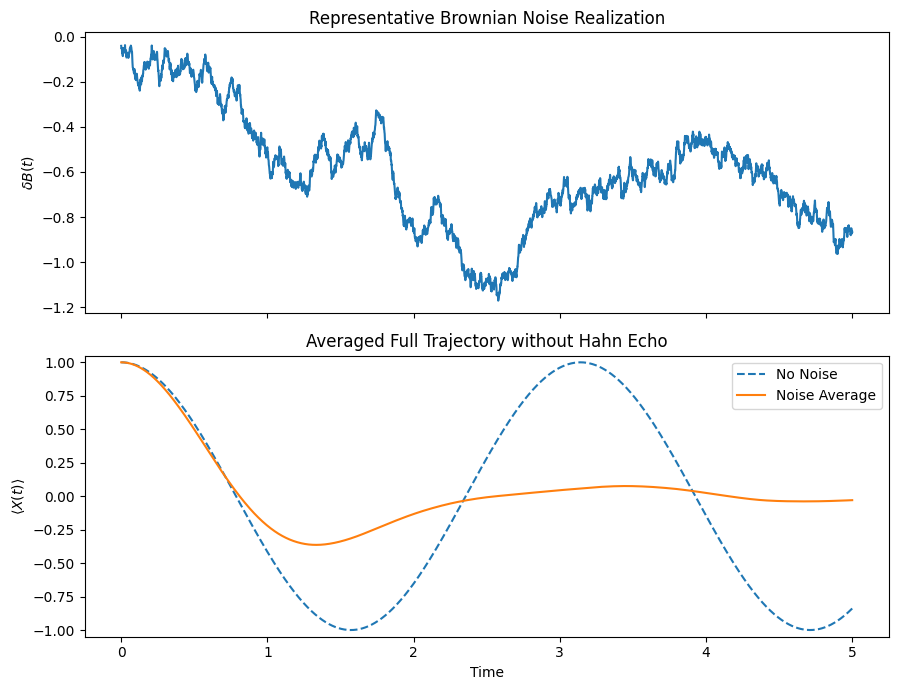

In [9]:
representativeColor = "brownian"
noiseData = noiseDataDictionary[representativeColor]
timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials = trajectoryDictionary[representativeColor]

figure, axes = plt.subplots(2, 1, figsize = (9, 7), sharex = True)
axes[0].plot(timeList, noiseData[0])
axes[0].set_ylabel(r"$\delta B(t)$")
axes[0].set_title("Representative "+representativeColor.capitalize()+" Noise Realization")
axes[1].plot(timeList, noNoiseNoEcho, linestyle = "--", label = "No Noise")
axes[1].plot(timeList, averageNoEcho, label = "Noise Average")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$\langle X(t)\rangle$")
axes[1].set_title("Averaged Full Trajectory without Hahn Echo")
axes[1].set_ylim(-1.05, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()

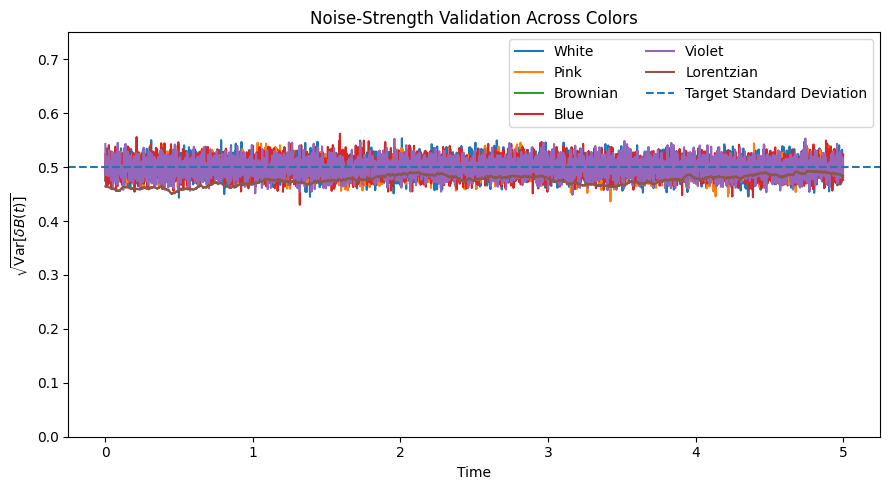

In [10]:
plt.figure(figsize = (9, 5))

for color in colorList:
    noiseStandardDeviation = np.std(noiseDataDictionary[color], axis = 0)
    plt.plot(timeList, noiseStandardDeviation, label = color.capitalize())

plt.axhline(sigma, linestyle = "--", label = "Target Standard Deviation")
plt.xlabel("Time")
plt.ylabel(r"$\sqrt{\mathrm{Var}[\delta B(t)]}$")
plt.title("Noise-Strength Validation Across Colors")
plt.ylim(0.0, 1.5*sigma)
plt.legend(ncol = 2)
plt.tight_layout()
plt.show()

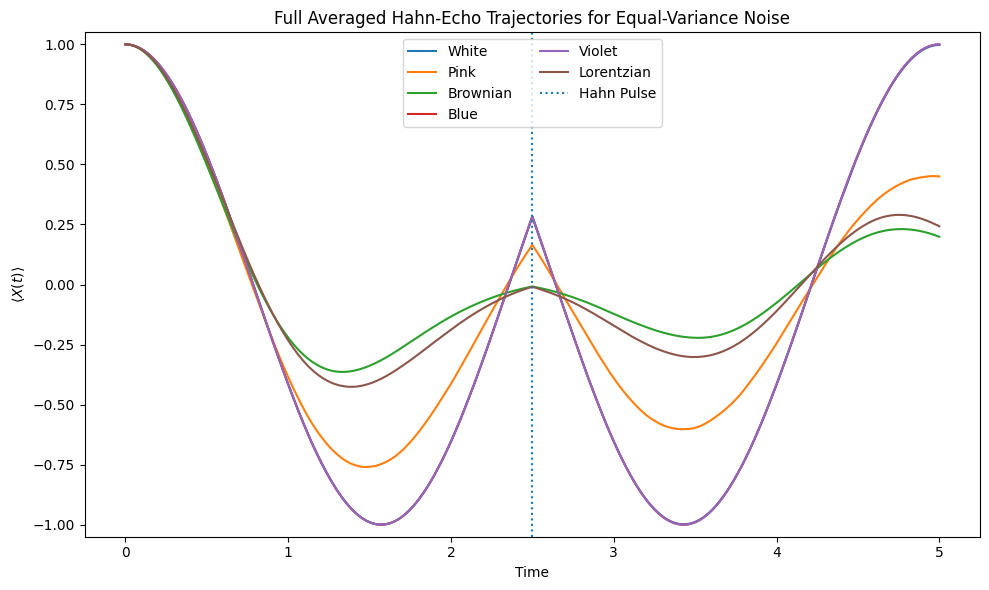

In [11]:
plt.figure(figsize = (10, 6))

for color in colorList:
    timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials = trajectoryDictionary[color]
    plt.plot(timeList, averageEcho, label = color.capitalize())

plt.axvline(tmax/2.0, linestyle = ":", label = "Hahn Pulse")
plt.xlabel("Time")
plt.ylabel(r"$\langle X(t)\rangle$")
plt.title("Full Averaged Hahn-Echo Trajectories for Equal-Variance Noise")
plt.ylim(-1.05, 1.05)
plt.legend(ncol = 2)
plt.tight_layout()
plt.show()

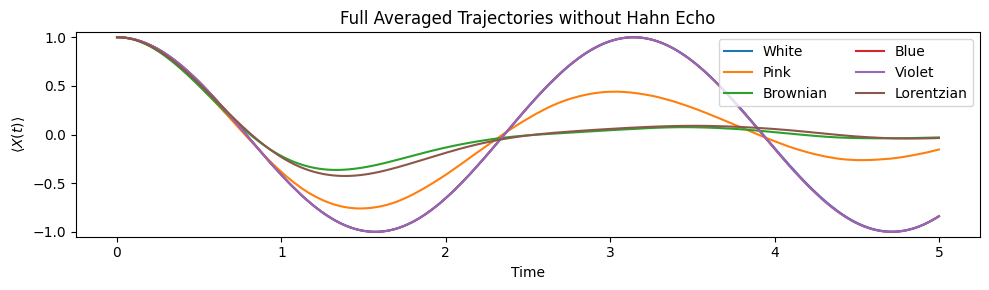

In [40]:
plt.figure(figsize = (10, 3))

for color in colorList:
    timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials = trajectoryDictionary[color]
    plt.plot(timeList, averageNoEcho, label = color.capitalize())

plt.xlabel("Time")
plt.ylabel(r"$\langle X(t)\rangle$")
plt.title("Full Averaged Trajectories without Hahn Echo")
plt.ylim(-1.05, 1.05)
plt.legend(ncol = 2)
plt.tight_layout()
plt.show()

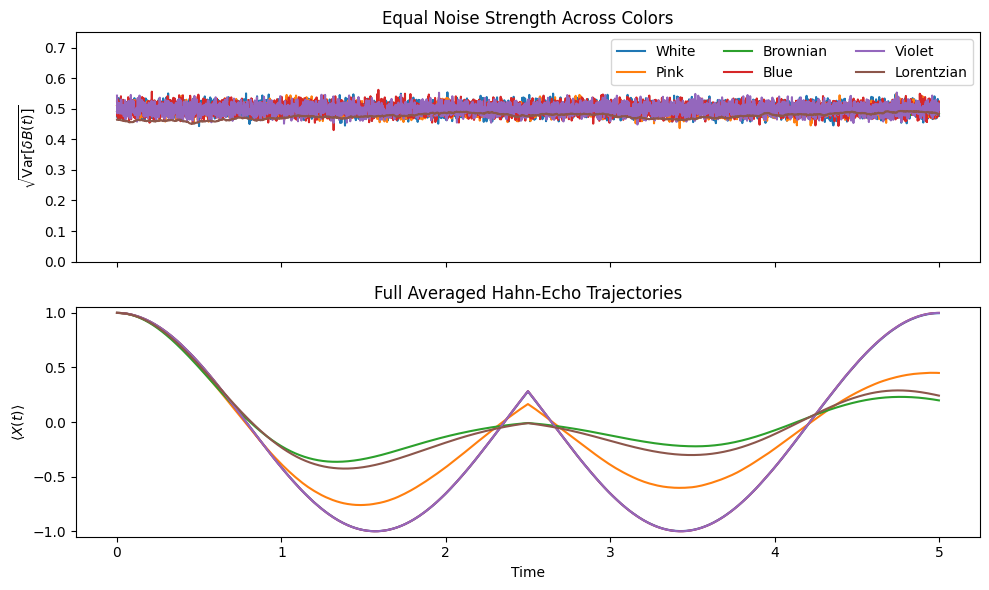

In [42]:
figure, axes = plt.subplots(2, 1, figsize = (10, 6), sharex = True)

for color in colorList:
    noiseStandardDeviation = np.std(noiseDataDictionary[color], axis = 0)
    axes[0].plot(timeList, noiseStandardDeviation, label = color.capitalize())

#axes[0].axhline(sigma, linestyle = "--", label = "Target")
axes[0].set_ylabel(r"$\sqrt{\mathrm{Var}[\delta B(t)]}$")
axes[0].set_title("Equal Noise Strength Across Colors")
axes[0].set_ylim(0.0, 1.5*sigma)
axes[0].legend(ncol = 3)

for color in colorList:
    timeList, averageNoEcho, averageEcho, noNoiseNoEcho, noNoiseEcho, xNoEchoTrials, xEchoTrials = trajectoryDictionary[color]
    axes[1].plot(timeList, averageEcho, label = color.capitalize())

#axes[1].axvline(tmax/2.0, linestyle = ":")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$\langle X(t)\rangle$")
axes[1].set_title("Full Averaged Hahn-Echo Trajectories")
axes[1].set_ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()

In [14]:
print("Target theoretical variance:", sigma**2)
print()

for color in colorList:
    noiseData = noiseDataDictionary[color]
    croppedRecordVariance = np.mean(np.var(noiseData, axis = 1))
    ensembleVariance = np.mean(np.var(noiseData, axis = 0))
    print(color.capitalize())
    print("PSD theoretical variance:", theoreticalVarianceDictionary[color])
    print("Average cropped-record variance:", croppedRecordVariance)
    print("Average ensemble variance:", ensembleVariance)
    print()

Target theoretical variance: 0.25

White
PSD theoretical variance: 0.25
Average cropped-record variance: 0.2500271581539194
Average ensemble variance: 0.24957640507352588

Pink
PSD theoretical variance: 0.2500000000000001
Average cropped-record variance: 0.21424021667223184
Average ensemble variance: 0.24612873266600857

Brownian
PSD theoretical variance: 0.24999999999999994
Average cropped-record variance: 0.06740084457790178
Average ensemble variance: 0.24678560443222725

Blue
PSD theoretical variance: 0.25
Average cropped-record variance: 0.24990091376379722
Average ensemble variance: 0.2493958921654341

Violet
PSD theoretical variance: 0.24999999999999994
Average cropped-record variance: 0.24922783206264398
Average ensemble variance: 0.24873473457149942

Lorentzian
PSD theoretical variance: 0.24999999999999994
Average cropped-record variance: 0.06881015590078596
Average ensemble variance: 0.2263476774397155



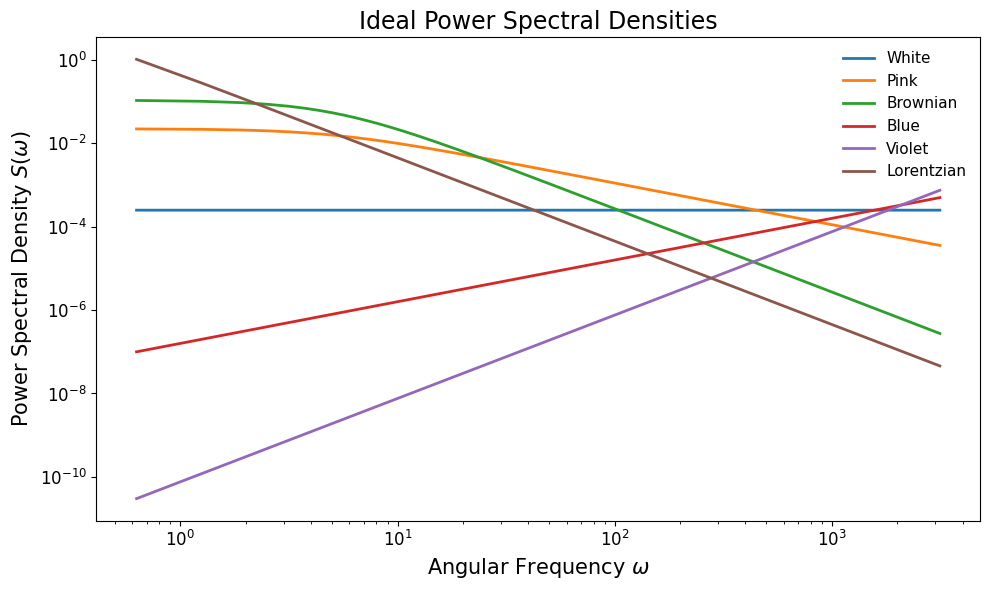

In [25]:
plotIdealPSDs(sigma, tau, deltat, tmax)

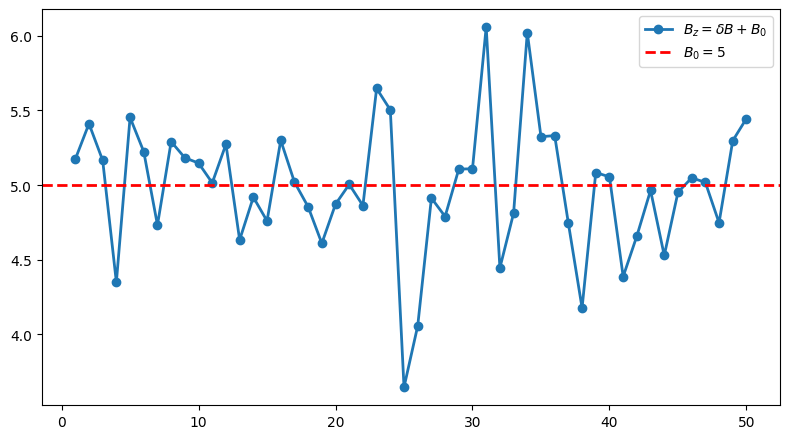

In [73]:
B0 = 5.0
sigma = 0.5
numTrials = 50
seed = 1

rng = np.random.default_rng(seed)

trialList = np.arange(1, numTrials + 1)
BzValues = rng.normal(B0, sigma, numTrials)

plt.figure(figsize=(8, 4.5))
plt.plot(trialList, BzValues, linewidth=2, marker = 'o', label = "$B_z = δB + B_0$")
plt.axhline(B0, color="red", linestyle="--", linewidth=2, label=r"$B_0 = 5$")

#plt.title("Constant Magnetic-Field Noise", fontsize = 20)
#plt.xlabel("Trial Number", fontsize = 15)
#plt.ylabel(r"$B_z$", fontsize = 15)
plt.legend()
plt.tight_layout()
plt.show()

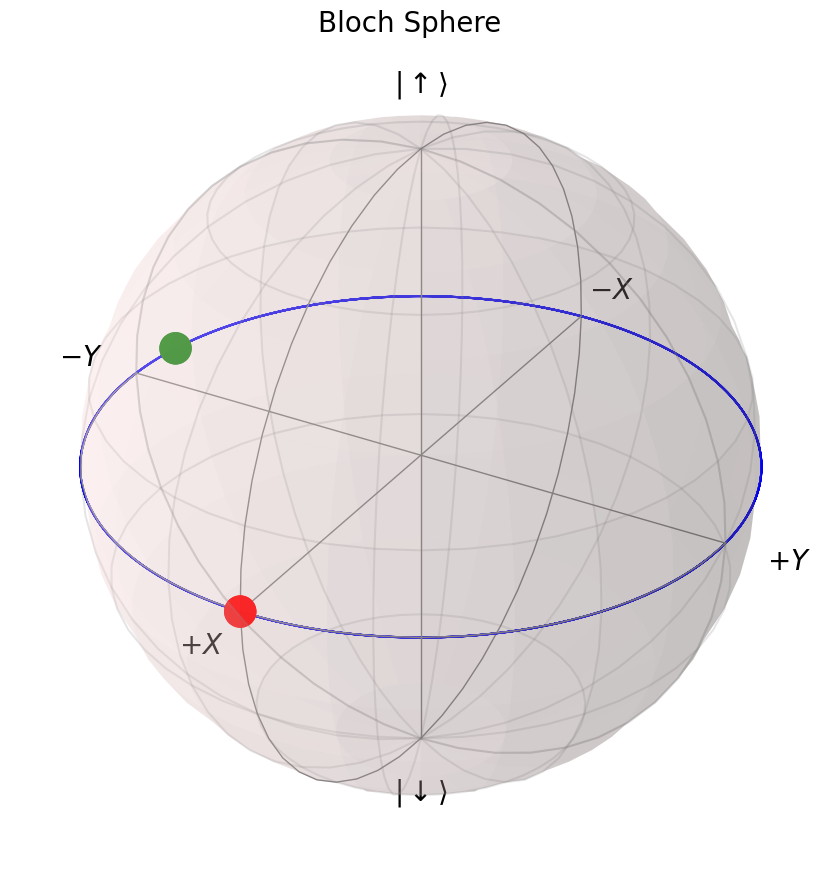

In [69]:

from qutip import Bloch

B0 = 5.0
sigma = 0.5
tau = 1.0
deltat = 0.001
tmax = 2.0

np.random.seed(1)

steps = int(tmax / deltat)
noise = np.zeros(steps + 1)
noise[0] = np.random.normal(0, sigma)

a = np.exp(-deltat / tau)

for i in range(steps):
    noise[i + 1] = (
        a * noise[i]
        + sigma * np.sqrt(1 - a**2) * np.random.normal()
    )

BzList = B0 + noise
timeList = np.arange(len(BzList)) * deltat

phaseList = np.zeros(len(BzList))
phaseList[1:] = np.cumsum(BzList[:-1]) * deltat

x = np.cos(2 * phaseList)
y = np.sin(2 * phaseList)
z = np.zeros(len(timeList))

fig = plt.figure(figsize=(8, 8))

b = Bloch(fig=fig)

b.point_size = [25, 500, 500]

b.add_points([x, y, z], meth="l", colors="blue")
b.add_points([x[0], y[0], z[0]], marker="o", colors="red")
b.add_points([x[-1], y[-1], z[-1]], marker="o", colors="green")

b.xlabel = [r"$+X$", r"$-X$"]
b.ylabel = [r"$+Y$", r"$-Y$"]
b.zlabel = [r"$|\uparrow\rangle$", r"$|\downarrow\rangle$"]

b.render()

b.axes.set_title("Bloch Sphere", fontsize=20, pad=25)

plt.show()

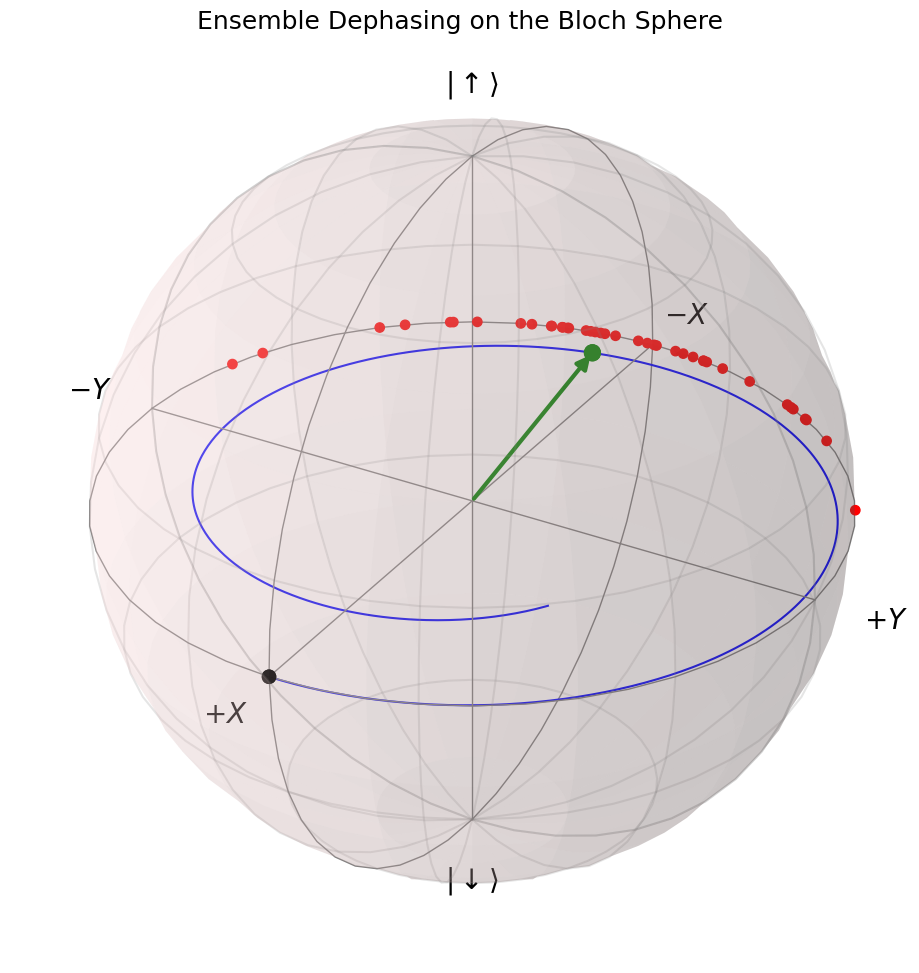

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch

B0 = 3.0
sigma = 0.5
tmax = 1.2
deltat = 0.002
numTrials = 500
selectedTime = 0.55
numDisplayedPoints = 40
seed = 1

rng = np.random.default_rng(seed)

timeList = np.arange(
    0.0,
    tmax + deltat,
    deltat
)

BValues = rng.normal(
    B0,
    sigma,
    numTrials
)

phaseData = (
    2.0
    * BValues[:, None]
    * timeList[None, :]
)

xData = np.cos(phaseData)
yData = np.sin(phaseData)

averageX = np.mean(
    xData,
    axis=0
)

averageY = np.mean(
    yData,
    axis=0
)

averageZ = np.zeros_like(
    timeList
)

selectedIndex = np.argmin(
    np.abs(
        timeList
        - selectedTime
    )
)

displayedIndices = rng.choice(
    numTrials,
    size=numDisplayedPoints,
    replace=False
)

individualX = xData[
    displayedIndices,
    selectedIndex
]

individualY = yData[
    displayedIndices,
    selectedIndex
]

individualZ = np.zeros(
    numDisplayedPoints
)

selectedAverageX = averageX[
    selectedIndex
]

selectedAverageY = averageY[
    selectedIndex
]

selectedAverageZ = 0.0

fig = plt.figure(
    figsize=(9, 9)
)

b = Bloch(
    fig=fig
)

b.point_size = [
    20,
    45,
    130,
    90
]

b.add_points(
    [
        averageX,
        averageY,
        averageZ
    ],
    meth="l",
    colors="blue"
)

b.add_points(
    [
        individualX,
        individualY,
        individualZ
    ],
    meth="s",
    marker="o",
    colors="red"
)

b.add_points(
    [
        selectedAverageX,
        selectedAverageY,
        selectedAverageZ
    ],
    marker="o",
    colors="green"
)

b.add_points(
    [
        averageX[0],
        averageY[0],
        averageZ[0]
    ],
    marker="o",
    colors="black"
)

b.add_vectors(
    [
        selectedAverageX,
        selectedAverageY,
        selectedAverageZ
    ],
    colors="green"
)

b.xlabel = [
    r"$+X$",
    r"$-X$"
]

b.ylabel = [
    r"$+Y$",
    r"$-Y$"
]

b.zlabel = [
    r"$|\uparrow\rangle$",
    r"$|\downarrow\rangle$"
]

b.render()

b.axes.set_title(
    "Ensemble Dephasing on the Bloch Sphere",
    fontsize=18,
    pad=25
)

plt.show()

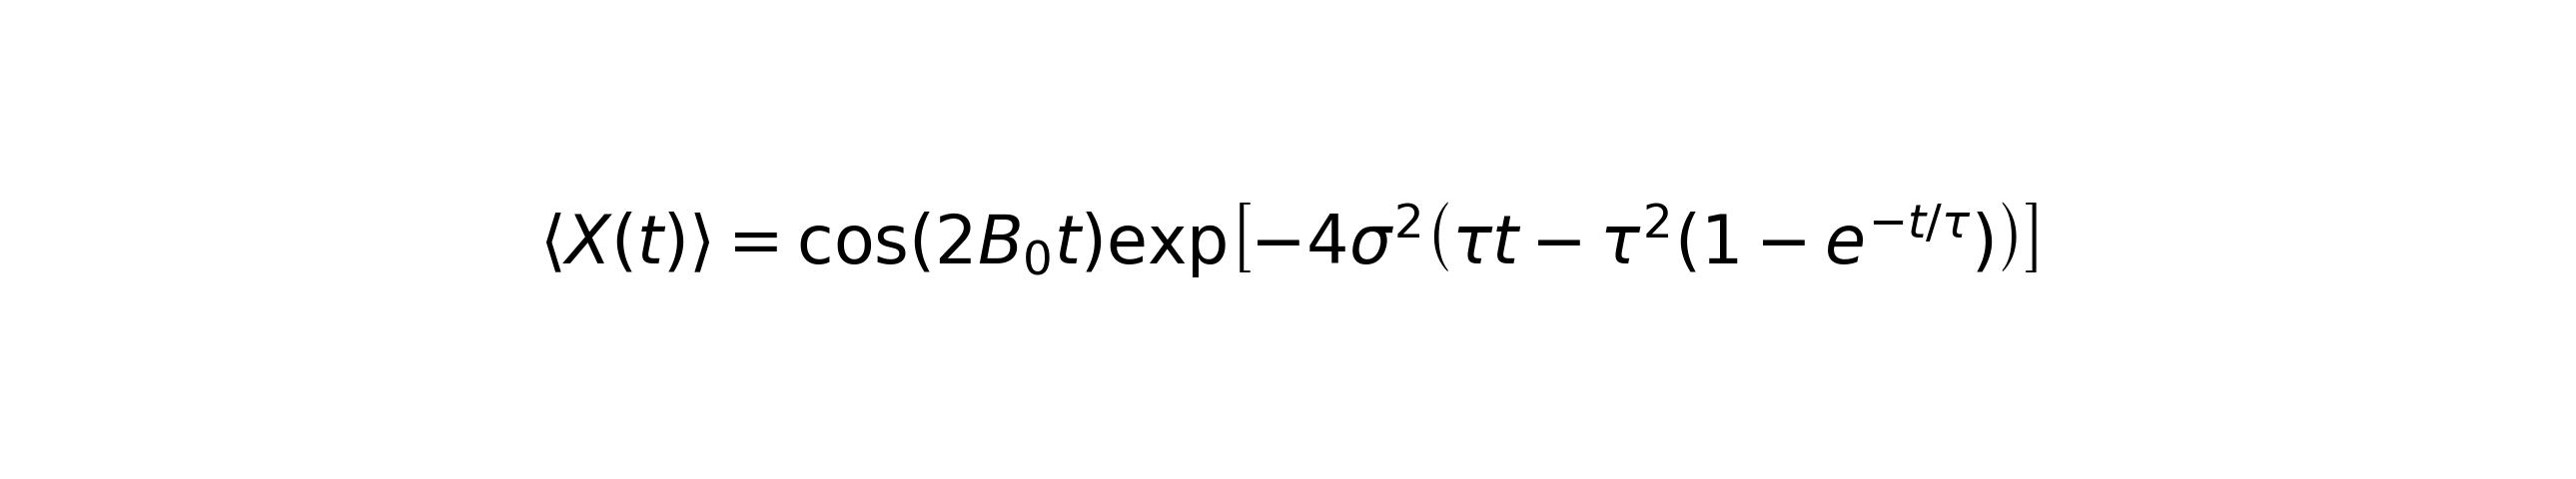

In [74]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 2.5), dpi=200)

ax.text(
    0.5,
    0.5,
    r"$\langle X(t)\rangle"
    r"=\cos(2B_0t)"
    r"\exp\!\left[-4\sigma^2"
    r"\left(\tau t-\tau^2\left(1-e^{-t/\tau}\right)\right)"
    r"\right]$",
    fontsize=24,
    ha="center",
    va="center"
)

ax.axis("off")
plt.tight_layout()
plt.show()

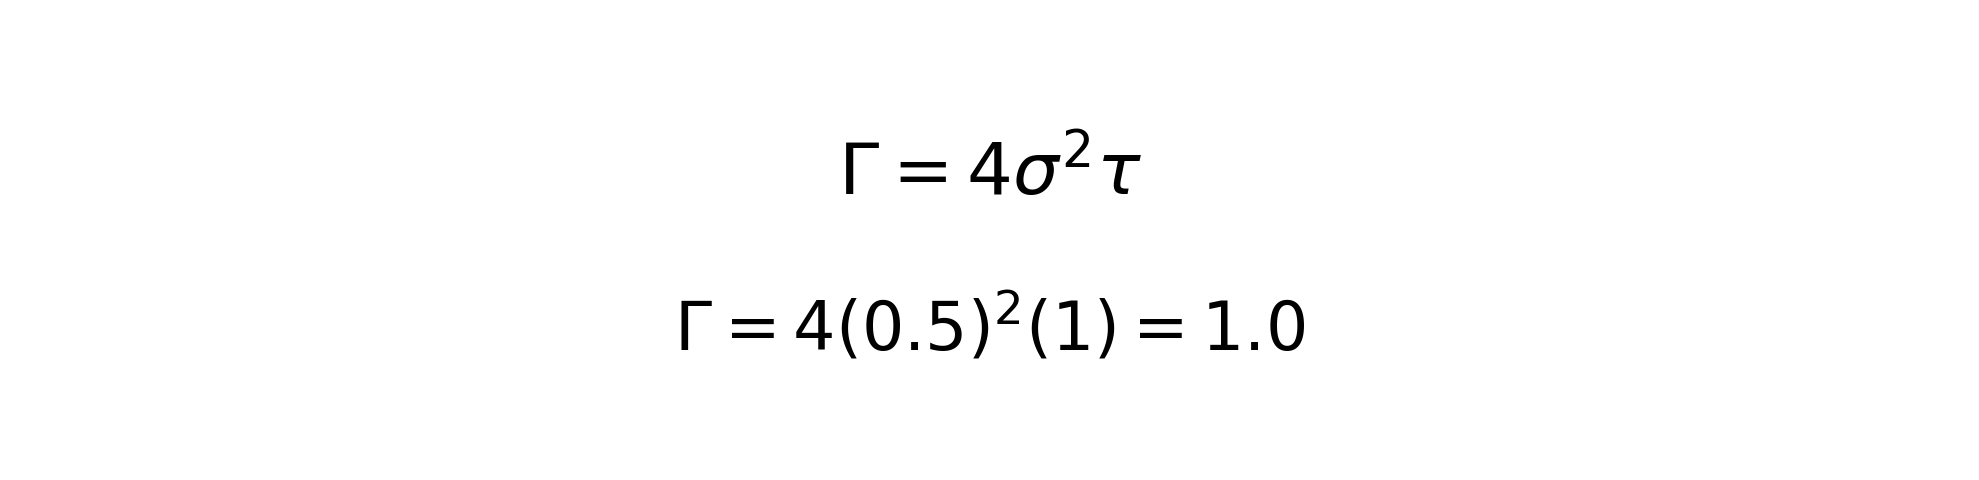

In [75]:
import matplotlib.pyplot as plt

sigma = 0.5
tau = 1.0
decayRate = 4 * sigma**2 * tau

fig, ax = plt.subplots(figsize=(10, 2.5), dpi=200)

ax.text(
    0.5,
    0.65,
    r"$\Gamma=4\sigma^2\tau$",
    fontsize=26,
    ha="center",
    va="center"
)

ax.text(
    0.5,
    0.30,
    rf"$\Gamma=4(0.5)^2(1)={decayRate:.1f}$",
    fontsize=24,
    ha="center",
    va="center"
)

ax.axis("off")
plt.tight_layout()
plt.show()

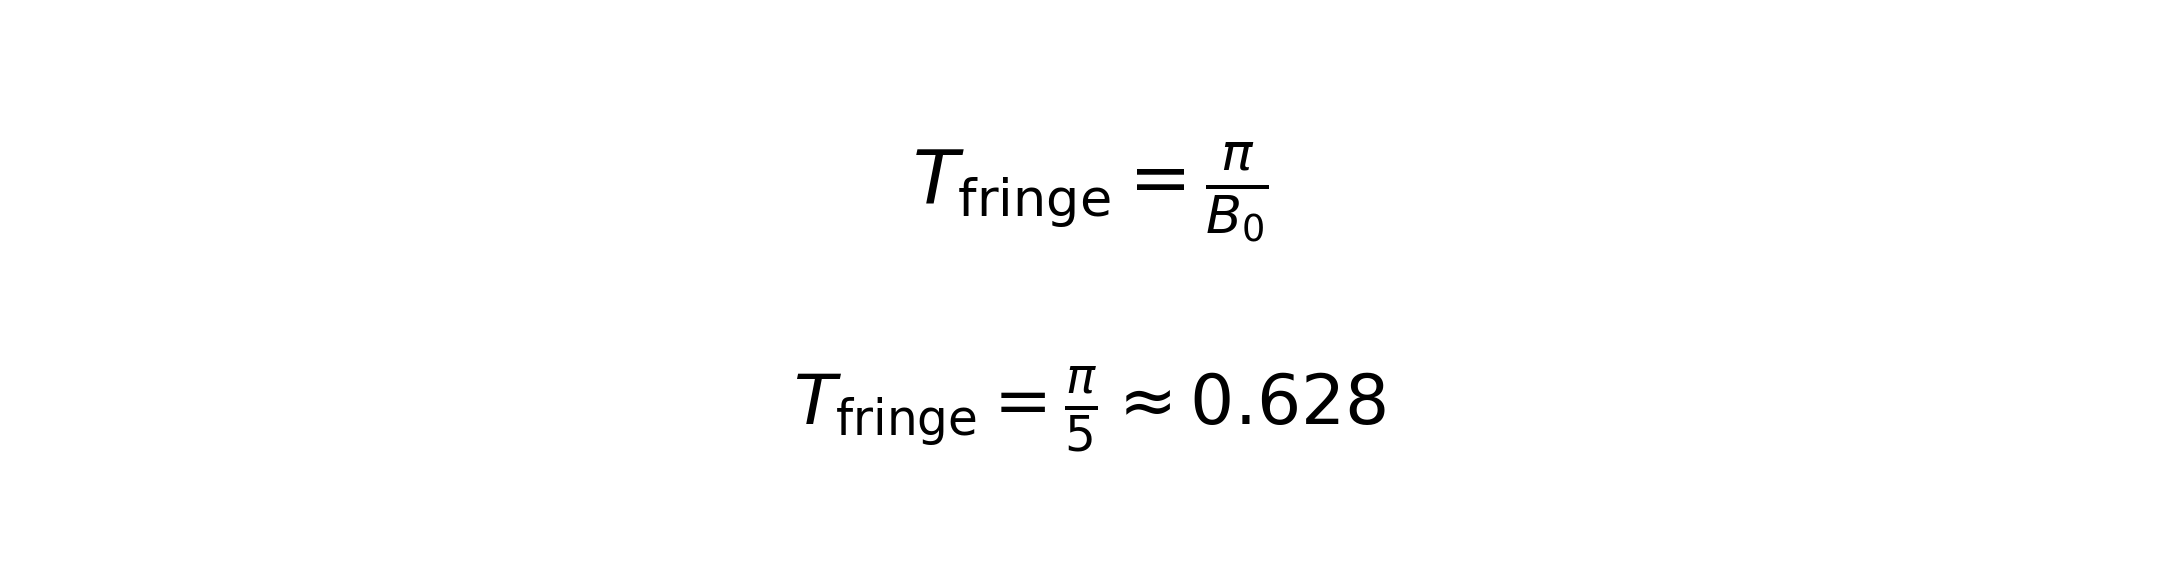

In [77]:
import numpy as np
import matplotlib.pyplot as plt

B0 = 5.0
fringePeriod = np.pi / B0

fig, ax = plt.subplots(figsize=(11, 3), dpi=200)

ax.text(
    0.5,
    0.68,
    r"$T_{\mathrm{fringe}}"
    r"=\frac{\pi}{B_0}$",
    fontsize=27,
    ha="center",
    va="center"
)

ax.text(
    0.5,
    0.28,
    rf"$T_{{\mathrm{{fringe}}}}"
    rf"=\frac{{\pi}}{{5}}"
    rf"\approx {fringePeriod:.3f}$",
    fontsize=25,
    ha="center",
    va="center"
)

ax.axis("off")
plt.tight_layout()
plt.show()

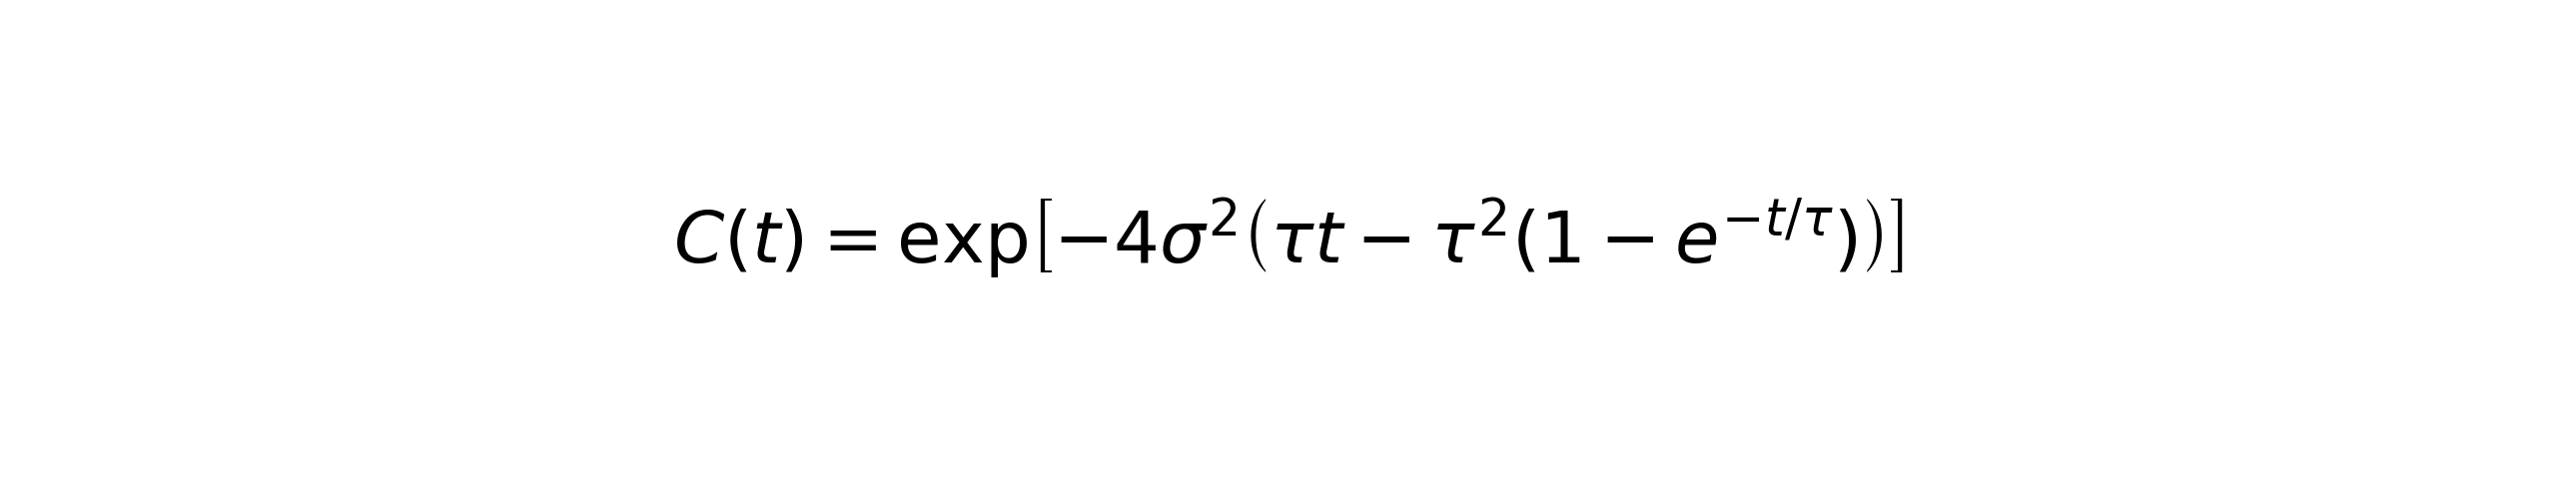

In [78]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 2.5), dpi=200)
ax.text(
    0.5,
    0.5,
    r"$C(t)=\exp\!\left[-4\sigma^2"
    r"\left(\tau t-\tau^2\left(1-e^{-t/\tau}\right)\right)"
    r"\right]$",
    fontsize=26,
    ha="center",
    va="center"
)
ax.axis("off")
plt.tight_layout()
plt.show()

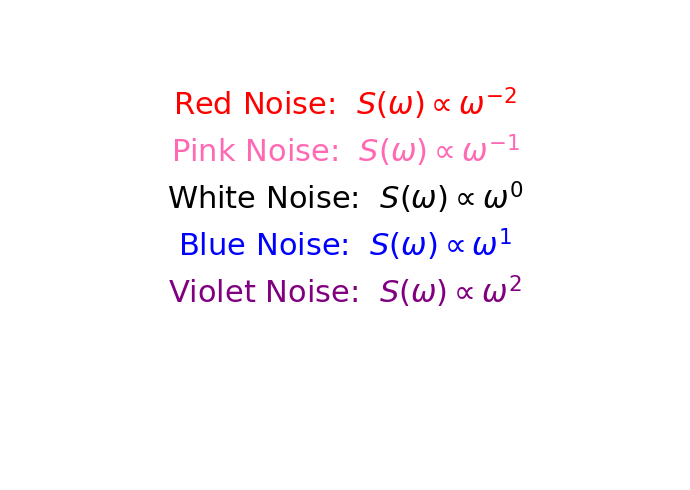

In [79]:
import matplotlib.pyplot as plt

noiseInfo = [
    ("Red Noise", r"$S(\omega)\propto\omega^{-2}$", "red"),
    ("Pink Noise", r"$S(\omega)\propto\omega^{-1}$", "hotpink"),
    ("White Noise", r"$S(\omega)\propto\omega^{0}$", "black"),
    ("Blue Noise", r"$S(\omega)\propto\omega^{1}$", "blue"),
    ("Violet Noise", r"$S(\omega)\propto\omega^{2}$", "purple")
]

fig, ax = plt.subplots(figsize=(7, 5))

yPositions = [0.8, 0.7, 0.6, 0.5, 0.4]

for (noiseName, psdEquation, color), yPosition in zip(
    noiseInfo,
    yPositions
):
    ax.text(
        0.5,
        yPosition,
        f"{noiseName}:  {psdEquation}",
        color=color,
        fontsize=22,
        ha="center",
        va="center"
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()

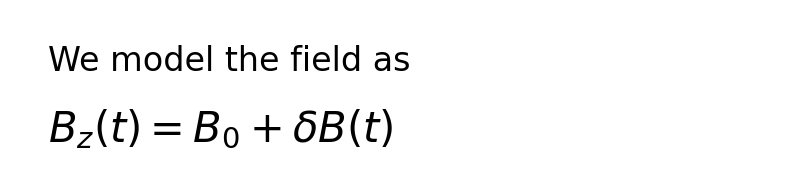

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2))

ax.axis("off")

ax.text(
    0.05,
    0.70,
    "We model the field as",
    fontsize=24,
    ha="left",
    va="center"
)

ax.text(
    0.05,
    0.30,
    r"$B_z(t)=B_0+\delta B(t)$",
    fontsize=30,
    ha="left",
    va="center"
)

plt.tight_layout()
plt.savefig(
    "magnetic_field_model.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()